# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:

%pip -q install duckdb huggingface_hub

In [3]:
import os, getpass

# Token order: env var -> Colab Secret -> prompt (last resort).
# Use a Colab Secret named HF_TOKEN (the key panel on the left) so the prompt never
# fires: if Colab reconnects while a getpass prompt is open, the kernel waits on it
# forever ('Resuming execution...') and you have to restart the runtime.
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

In [4]:
import duckdb

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':                f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':                 f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample':          f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':             f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')

dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


In [5]:
clients = con.sql(f"""
    SELECT client_hash_id, access_profile, gsc_data_start, ga4_data_start
    FROM {TABLES['dim_clients']}
    ORDER BY gsc_data_start NULLS LAST
""").df()

print('clients with 12+ months of GSC history:',
      (clients['gsc_data_start'] <= clients['gsc_data_start'].dropna().max() - __import__('pandas').Timedelta(days=365)).sum())
clients.head(10)

clients with 12+ months of GSC history: 4


,client_hash_id,access_profile,gsc_data_start,ga4_data_start
0,client_9958f0a7ae1df715,gsc_and_ga4,2025-01-27,2025-10-29
1,client_ff644d8251367cbb,gsc_and_ga4,2025-01-27,2025-10-29
2,client_73cda7b4e4f265ea,gsc_and_ga4,2025-02-11,2026-03-24
3,client_fef1a8f436438636,gsc_and_ga4,2025-03-11,2026-03-06
4,client_62f4a7e64f5e0096,gsc_only,2025-06-07,NaT
5,client_b10cb2997d0c7c86,gsc_and_ga4,2025-06-18,2025-11-15
6,client_65de48885f4ef01b,gsc_and_ga4,2025-06-21,2026-02-19
7,client_c182d11e4862a37d,gsc_and_ga4,2025-06-21,2026-02-20
8,client_3197e6291363b4db,gsc_and_ga4,2025-06-29,2025-11-09
9,client_625b6439094e23e4,gsc_and_ga4,2025-07-01,2026-02-19


In [6]:
features = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d FROM {TABLES['fact_daily']}
    ),
    windowed AS (
        SELECT f.client_hash_id, f.content_hash_id,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_last30,
               SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_prev30,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_clicks ELSE 0 END)      AS clk_last30,
               AVG(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_avg_position END)       AS pos_last30
        FROM {TABLES['fact_daily']} f, bounds b
        WHERE f.report_date > b.end_d - INTERVAL 60 DAY
        GROUP BY 1, 2
        HAVING imp_prev30 >= 100
    )
    SELECT * FROM windowed
""").df()

print(f'{len(features):,} content items with enough history')
features.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

111,247 content items with enough history


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30
0,client_62f4a7e64f5e0096,content_17d994b99d470434,252.0,827.0,1.0,41.917435
1,client_62f4a7e64f5e0096,content_9e6d399bb7df2d21,411.0,874.0,4.0,40.678875
2,client_62f4a7e64f5e0096,content_889961fe0fd51a4b,2140.0,2664.0,6.0,7.070556
3,client_62f4a7e64f5e0096,content_7e67ece7486a4851,101.0,183.0,0.0,35.997698
4,client_62f4a7e64f5e0096,content_762f7da095bfd414,141.0,261.0,0.0,12.166371


In [7]:
qsignals = con.sql(f"""
    SELECT content_hash_id,
           ANY_VALUE(content_visible_query_count)     AS visible_queries,
           ANY_VALUE(rare_impressions_share)          AS rare_share,
           ANY_VALUE(anonymized_impressions_share)    AS anon_share,
           MAX(impressions_90d)                       AS top_query_impressions,
           SUM(impressions_90d)                       AS kept_impressions
    FROM {TABLES['fact_query_90d']}
    GROUP BY content_hash_id
""").df()

qsignals['top_query_share'] = qsignals['top_query_impressions'] / qsignals['kept_impressions']
data = features.merge(qsignals, on='content_hash_id', how='left')
print(f'joined: {len(data):,} rows')
data.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

joined: 111,247 rows


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share
0,client_62f4a7e64f5e0096,content_17d994b99d470434,252.0,827.0,1.0,41.917435,8.0,0.136531,0.239391,1223.0,1353.0,0.903917
1,client_62f4a7e64f5e0096,content_9e6d399bb7df2d21,411.0,874.0,4.0,40.678875,38.0,0.146092,0.336034,900.0,2173.0,0.414174
2,client_62f4a7e64f5e0096,content_889961fe0fd51a4b,2140.0,2664.0,6.0,7.070556,42.0,0.064587,0.803004,103.0,1146.0,0.089878
3,client_62f4a7e64f5e0096,content_7e67ece7486a4851,101.0,183.0,0.0,35.997698,4.0,0.384248,0.408115,38.0,87.0,0.436782
4,client_62f4a7e64f5e0096,content_762f7da095bfd414,141.0,261.0,0.0,12.166371,3.0,0.104607,0.860845,15.0,36.0,0.416667


In [8]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

data['is_declining'] = (data['imp_last30'] < 0.8 * data['imp_prev30']).astype(int)

feature_cols = ['imp_prev30', 'visible_queries', 'rare_share', 'anon_share', 'top_query_share']
model_data = data.dropna(subset=feature_cols)
X, y = model_data[feature_cols], model_data['is_declining']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_tr, y_tr)

print(f'base rate (always predict majority): {max(y_te.mean(), 1 - y_te.mean()):.3f}')
print(classification_report(y_te, model.predict(X_te), digits=3))

base rate (always predict majority): 0.633
              precision    recall  f1-score   support

           0      0.539     0.329     0.408      9389
           1      0.682     0.837     0.751     16162

    accuracy                          0.650     25551
   macro avg      0.610     0.583     0.580     25551
weighted avg      0.629     0.650     0.625     25551



In [9]:
features_90d = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d FROM {TABLES['fact_daily']}
    ),
    windowed AS (
        SELECT f.client_hash_id, f.content_hash_id,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_last30,
               SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
                        AND f.report_date >  b.end_d - INTERVAL 60 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_mid30,
               SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 60 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_prev30,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_clicks ELSE 0 END)      AS clk_last30,
               AVG(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_avg_position END)       AS pos_last30
        FROM {TABLES['fact_daily']} f, bounds b
        WHERE f.report_date > b.end_d - INTERVAL 90 DAY
        GROUP BY 1, 2
        HAVING imp_prev30 >= 150          -- your custom threshold (was 100 in the 60-day version)
    )
    SELECT * FROM windowed
""").df()

print(f'{len(features_90d):,} content items with enough history (90-day window)')
features_90d.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

95,895 content items with enough history (90-day window)


,client_hash_id,content_hash_id,imp_last30,imp_mid30,imp_prev30,clk_last30,pos_last30
0,client_e547b89c05043229,content_e1f6d0c859ba9dc4,195.0,301.0,253.0,0.0,23.401005
1,client_e547b89c05043229,content_48537762b74f5b34,208.0,147.0,396.0,0.0,28.054512
2,client_e547b89c05043229,content_27b27b5e13d4e6b7,134.0,239.0,185.0,1.0,24.978010
3,client_e547b89c05043229,content_8c2c3dab1f1e875f,379.0,745.0,714.0,0.0,34.729708
4,client_e547b89c05043229,content_5af024b82aa36744,254.0,159.0,181.0,1.0,8.191330


In [10]:
pos_volatility = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d FROM {TABLES['fact_daily']}
    )
    SELECT f.content_hash_id,
           STDDEV_POP(f.gsc_avg_position) AS pos_volatility_last30
    FROM {TABLES['fact_daily']} f, bounds b
    WHERE f.report_date > b.end_d - INTERVAL 30 DAY
    GROUP BY 1
""").df()

qsignals = con.sql(f"""
    SELECT content_hash_id,
           ANY_VALUE(content_visible_query_count)     AS visible_queries,
           ANY_VALUE(rare_impressions_share)          AS rare_share,
           ANY_VALUE(anonymized_impressions_share)    AS anon_share,
           MAX(impressions_90d)                       AS top_query_impressions,
           SUM(impressions_90d)                       AS kept_impressions
    FROM {TABLES['fact_query_90d']}
    GROUP BY content_hash_id
""").df()

qsignals['top_query_share'] = qsignals['top_query_impressions'] / qsignals['kept_impressions']

data_90d = (features_90d
            .merge(qsignals, on='content_hash_id', how='left')
            .merge(pos_volatility, on='content_hash_id', how='left'))

print(f'joined: {len(data_90d):,} rows')
data_90d.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

joined: 95,895 rows


,client_hash_id,content_hash_id,imp_last30,imp_mid30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share,pos_volatility_last30
0,client_e547b89c05043229,content_e1f6d0c859ba9dc4,195.0,301.0,253.0,0.0,23.401005,4.0,0.130841,0.562083,121.0,230.0,0.526087,9.206046
1,client_e547b89c05043229,content_48537762b74f5b34,208.0,147.0,396.0,0.0,28.054512,1.0,0.169108,0.797603,25.0,25.0,1.000000,17.180979
2,client_e547b89c05043229,content_27b27b5e13d4e6b7,134.0,239.0,185.0,1.0,24.978010,5.0,0.186380,0.620072,33.0,108.0,0.305556,8.802450
3,client_e547b89c05043229,content_8c2c3dab1f1e875f,379.0,745.0,714.0,0.0,34.729708,12.0,0.056039,0.817193,37.0,233.0,0.158798,13.434683
4,client_e547b89c05043229,content_5af024b82aa36744,254.0,159.0,181.0,1.0,8.191330,4.0,0.104377,0.789562,24.0,63.0,0.380952,6.861256


In [11]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

data_90d['is_declining'] = (data_90d['imp_last30'] < 0.8 * data_90d['imp_mid30']).astype(int)

feature_cols_90d = ['imp_mid30', 'visible_queries', 'rare_share', 'anon_share',
                     'top_query_share', 'pos_volatility_last30']
model_data_90d = data_90d.dropna(subset=feature_cols_90d)

X = model_data_90d[feature_cols_90d]
y = model_data_90d['is_declining']
groups = model_data_90d['client_hash_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

# sanity check: no client should appear in both splits
assert set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]) == set()

model_grouped = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_tr, y_tr)

print(f'clients in train: {groups.iloc[train_idx].nunique()}, clients in test: {groups.iloc[test_idx].nunique()}')
print(f'base rate (always predict majority): {max(y_te.mean(), 1 - y_te.mean()):.3f}')
print(classification_report(y_te, model_grouped.predict(X_te), digits=3))


clients in train: 31, clients in test: 11
base rate (always predict majority): 0.701
              precision    recall  f1-score   support

           0      0.604     0.653     0.628      2693
           1      0.847     0.818     0.832      6320

    accuracy                          0.769      9013
   macro avg      0.726     0.735     0.730      9013
weighted avg      0.774     0.769     0.771      9013



## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

In [12]:
'''I chose Random Forest for this task because the goal is to identify pages that are likely to need content refresh. The relationship between search performance signals and declining performance may not be linear, and Random Forest can capture interactions between multiple features.

The model will use search-performance features such as previous impressions, query diversity, top-query share, and ranking volatility. The output will help rank pages for content review.

I am not choosing the model because it is more complex. It is useful only if it performs better than the Week-4 hand-written baseline on the same validation data and metric.'''

'I chose Random Forest for this task because the goal is to identify pages that are likely to need content refresh. The relationship between search performance signals and declining performance may not be linear, and Random Forest can capture interactions between multiple features.\n\nThe model will use search-performance features such as previous impressions, query diversity, top-query share, and ranking volatility. The output will help rank pages for content review.\n\nI am not choosing the model because it is more complex. It is useful only if it performs better than the Week-4 hand-written baseline on the same validation data and metric.'

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

In [13]:
'''Client A ──→ TRAIN

Client B ──→ TRAIN

Client C ──→ TEST'''

'Client A ──→ TRAIN\n\nClient B ──→ TRAIN\n\nClient C ──→ TEST'

In [15]:
from sklearn.model_selection import GroupShuffleSplit

feature_cols = [
    "imp_mid30",
    "visible_queries",
    "rare_share",
    "anon_share",
    "top_query_share",
    "pos_volatility_last30"
]

model_data = data_90d.dropna(
    subset=feature_cols + ["is_declining"]
).copy()

X = model_data[feature_cols]
y = model_data["is_declining"]
groups = model_data["client_hash_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training clients:", groups_train.nunique())
print("Testing clients:", groups_test.nunique())

assert set(groups_train) & set(groups_test) == set()

print("✓ No client appears in both train and test.")

Training rows: 78722
Testing rows: 9013
Training clients: 31
Testing clients: 11
✓ No client appears in both train and test.


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:, 1]

print("Model trained successfully.")

Model trained successfully.


In [17]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

print("Accuracy :", round(accuracy_score(y_test, pred), 3))
print("Precision:", round(precision_score(y_test, pred), 3))
print("Recall   :", round(recall_score(y_test, pred), 3))
print("F1       :", round(f1_score(y_test, pred), 3))

Accuracy : 0.769
Precision: 0.847
Recall   : 0.818
F1       : 0.832


In [18]:
ml_queue = model_data.iloc[test_idx].copy()

ml_queue["model_score"] = prob

ml_queue["action"] = "REFRESH_REVIEW"

ml_queue = ml_queue.sort_values(
    "model_score",
    ascending=False
)

ml_queue[
    [
        "content_hash_id",
        "model_score",
        "action"
    ]
].head(20)

,content_hash_id,model_score,action
15719,content_c853903d75202111,1.0,REFRESH_REVIEW
5015,content_413b439e1de86a41,1.0,REFRESH_REVIEW
63854,content_4c82c93a3ee8cba8,1.0,REFRESH_REVIEW
17054,content_217c3656e5a6f160,1.0,REFRESH_REVIEW
63884,content_3416d0ce01f62062,1.0,REFRESH_REVIEW
16700,content_7edb11238279d451,1.0,REFRESH_REVIEW
90921,content_9608a9827285f5fe,1.0,REFRESH_REVIEW
4131,content_49b2e63b2cb95768,1.0,REFRESH_REVIEW
16602,content_08431c2c79586e00,1.0,REFRESH_REVIEW
17286,content_c5648a87c30896d5,1.0,REFRESH_REVIEW


In [22]:
import pandas as pd
import os

# Ensure the output directory exists
os.makedirs("work/outputs", exist_ok=True)

# Save ml_queue as the baseline_action_score.csv
ml_queue.to_csv("work/outputs/baseline_action_score.csv", index=False)

baseline = pd.read_csv(
    "work/outputs/baseline_action_score.csv"
)

baseline.head()
print(baseline.columns.tolist())

['client_hash_id', 'content_hash_id', 'imp_last30', 'imp_mid30', 'imp_prev30', 'clk_last30', 'pos_last30', 'visible_queries', 'rare_share', 'anon_share', 'top_query_impressions', 'kept_impressions', 'top_query_share', 'pos_volatility_last30', 'is_declining', 'model_score', 'action']


In [23]:
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance

,feature,importance
5,pos_volatility_last30,0.287230
0,imp_mid30,0.191307
2,rare_share,0.163393
3,anon_share,0.145008
4,top_query_share,0.123396
1,visible_queries,0.089667


<Axes: title={'center': 'Random Forest Feature Importance'}, xlabel='feature'>

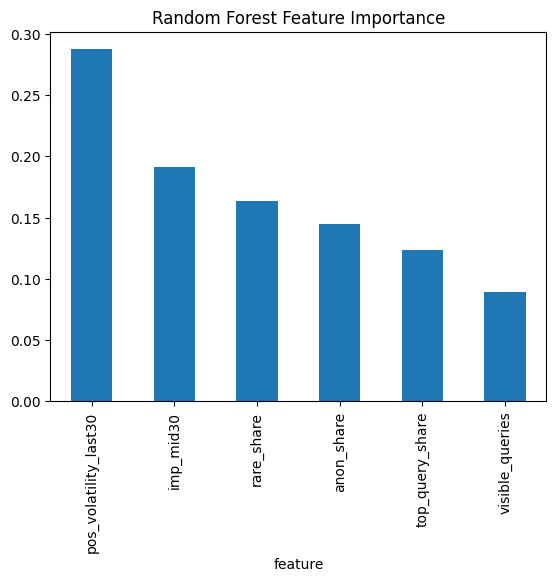

In [24]:
importance.plot(
    x="feature",
    y="importance",
    kind="bar",
    title="Random Forest Feature Importance",
    legend=False
)

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

In [25]:
errors = model_data.iloc[test_idx].copy()

errors["actual"] = y_test.values
errors["predicted"] = pred
errors["model_score"] = prob

errors["error_type"] = "Correct"

errors.loc[
    (errors["actual"] == 1) &
    (errors["predicted"] == 0),
    "error_type"
] = "False Negative"

errors.loc[
    (errors["actual"] == 0) &
    (errors["predicted"] == 1),
    "error_type"
] = "False Positive"

errors["error_type"].value_counts()

,count
error_type,
Correct,6927
False Negative,1151
False Positive,935


In [26]:
errors[
    errors["error_type"] == "False Positive"
][
    feature_cols + ["actual", "predicted", "model_score"]
].head(10)

,imp_mid30,visible_queries,rare_share,anon_share,top_query_share,pos_volatility_last30,actual,predicted,model_score
4061,2701.0,104.0,0.113652,0.071077,0.167458,4.614860,0,1,0.540
4075,3004.0,49.0,0.054972,0.730957,0.058738,3.833324,0,1,0.745
4115,480.0,15.0,0.082798,0.524625,0.305455,10.198071,0,1,0.655
4120,1488.0,37.0,0.454786,0.446148,0.080071,15.331496,0,1,0.800
4133,650.0,12.0,0.394054,0.502162,0.151042,30.007810,0,1,0.825
4152,691.0,14.0,0.346259,0.432551,0.279012,24.627493,0,1,0.945
4171,3598.0,12.0,0.030170,0.866922,0.718335,1.992286,0,1,0.760
4189,794.0,22.0,0.036329,0.431569,0.300177,7.448598,0,1,0.640
4192,132.0,8.0,0.034259,0.490741,0.311891,10.740009,0,1,0.655
4214,1168.0,34.0,0.089347,0.500505,0.299162,5.981303,0,1,0.590


In [27]:
errors[
    errors["error_type"] == "False Negative"
][
    feature_cols + ["actual", "predicted", "model_score"]
].head(10)

,imp_mid30,visible_queries,rare_share,anon_share,top_query_share,pos_volatility_last30,actual,predicted,model_score
4069,85.0,1.0,0.086111,0.883333,1.000000,9.618529,1,0,0.235
4076,99.0,1.0,0.124760,0.850288,1.000000,21.263586,1,0,0.240
4079,201.0,6.0,0.232906,0.551282,0.445545,6.763497,1,0,0.245
4093,282.0,2.0,0.164062,0.796875,0.520000,1.021376,1,0,0.445
4102,128.0,11.0,0.234628,0.328479,0.307407,18.724275,1,0,0.255
4109,205.0,5.0,0.127273,0.745455,0.233766,5.318432,1,0,0.350
4112,80.0,2.0,0.136591,0.832080,0.520000,6.086930,1,0,0.320
4116,7006.0,39.0,0.010771,0.799672,0.480531,0.698249,1,0,0.360
4118,148.0,4.0,0.136000,0.809000,0.363636,7.202852,1,0,0.205
4130,1287.0,19.0,0.176501,0.667611,0.198347,6.207874,1,0,0.460


In [28]:
''' The model does not classify every page correctly.
False positives are pages that the model considers likely to decline but that are not labelled as declining,
while false negatives are declining pages that the model misses.
These errors show why the model should be treated as a prioritization and decision-support tool rather than an automatic decision maker.

Feature importance shows which available search signals contributed most to the model's decisions.
However, feature importance does not establish causation or prove that any feature causes Google rankings or traffic to change.'''

" The model does not classify every page correctly.\nFalse positives are pages that the model considers likely to decline but that are not labelled as declining,\nwhile false negatives are declining pages that the model misses.\nThese errors show why the model should be treated as a prioritization and decision-support tool rather than an automatic decision maker.\n\nFeature importance shows which available search signals contributed most to the model's decisions.\nHowever, feature importance does not establish causation or prove that any feature causes Google rankings or traffic to change."

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.